In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("D:\\Data_Sets_Uso\\German Credit\\german_credit_data.csv")

In [3]:
pd.get_dummies(df)

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,24,2,3,1987,1,3,2,3,1,...,1,21,3,1,1,2,1,1,2,0
996,1,24,2,0,2303,1,5,4,3,2,...,1,45,3,2,1,3,2,1,2,0
997,4,21,4,0,12680,5,5,4,3,1,...,4,30,3,3,1,4,2,2,2,0
998,2,12,2,3,6468,5,1,2,3,1,...,4,52,3,2,1,4,2,2,2,0


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   laufkont  1000 non-null   int64
 1   laufzeit  1000 non-null   int64
 2   moral     1000 non-null   int64
 3   verw      1000 non-null   int64
 4   hoehe     1000 non-null   int64
 5   sparkont  1000 non-null   int64
 6   beszeit   1000 non-null   int64
 7   rate      1000 non-null   int64
 8   famges    1000 non-null   int64
 9   buerge    1000 non-null   int64
 10  wohnzeit  1000 non-null   int64
 11  verm      1000 non-null   int64
 12  alter     1000 non-null   int64
 13  weitkred  1000 non-null   int64
 14  wohn      1000 non-null   int64
 15  bishkred  1000 non-null   int64
 16  beruf     1000 non-null   int64
 17  pers      1000 non-null   int64
 18  telef     1000 non-null   int64
 19  gastarb   1000 non-null   int64
 20  kredit    1000 non-null   int64
dtypes: int64(21)
memory usage: 164.2 KB


laufkont    0
laufzeit    0
moral       0
verw        0
hoehe       0
sparkont    0
beszeit     0
rate        0
famges      0
buerge      0
wohnzeit    0
verm        0
alter       0
weitkred    0
wohn        0
bishkred    0
beruf       0
pers        0
telef       0
gastarb     0
kredit      0
dtype: int64

In [5]:
column_names = {
    'laufkont': 'cuenta_corriente',
    'laufzeit': 'duracion_meses',
    'moral': 'historial_credito',
    'verw': 'proposito',
    'hoehe': 'monto_credito',
    'sparkont': 'cuenta_ahorro',
    'beszeit': 'antiguedad_laboral',
    'rate': 'tasa_cuota_ingreso',
    'famges': 'estado_civil_sexo',
    'buerge': 'otras deudas',
    'wohnzeit':'tiempo_vivienda_actual',
    'verm': 'patrimonio',
    'alter': 'edad',
    'weitkred': 'otros_creditos',
    'wohn': 'vivienda',
    'bishkred': 'num_creditos_previos',
    'beruf': 'Trabajo',
    'pers': 'personas_dependientes',
    'telef': 'celular', 
    'gastarb': 'trabajador_extranjero', 
    'kredit': 'riesgo_crediticio'
}
df = df.rename(columns=column_names)

In [6]:
df.head()

,cuenta_corriente,duracion_meses,historial_credito,proposito,monto_credito,cuenta_ahorro,antiguedad_laboral,tasa_cuota_ingreso,estado_civil_sexo,otras deudas,...,patrimonio,edad,otros_creditos,vivienda,num_creditos_previos,Trabajo,personas_dependientes,celular,trabajador_extranjero,riesgo_crediticio
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [7]:
#Validacion de valores 0 y 1 para sckitlearn
df['riesgo_crediticio'].value_counts()
df['riesgo_crediticio'].value_counts(normalize=True)  

riesgo_crediticio
1    0.7
0    0.3
Name: proportion, dtype: float64

In [8]:
#En caso de que los valores en riesgo creiticio sean 0 y 1
#df['riesgo_crediticio'] = df['riesgo_crediticio'].map({1: 0, 2: 1})  # 0 = default/mal pagador

In [9]:
df.dtypes

cuenta_corriente          int64
duracion_meses            int64
historial_credito         int64
proposito                 int64
monto_credito             int64
cuenta_ahorro             int64
antiguedad_laboral        int64
tasa_cuota_ingreso        int64
estado_civil_sexo         int64
otras deudas              int64
tiempo_vivienda_actual    int64
patrimonio                int64
edad                      int64
otros_creditos            int64
vivienda                  int64
num_creditos_previos      int64
Trabajo                   int64
personas_dependientes     int64
celular                   int64
trabajador_extranjero     int64
riesgo_crediticio         int64
dtype: object

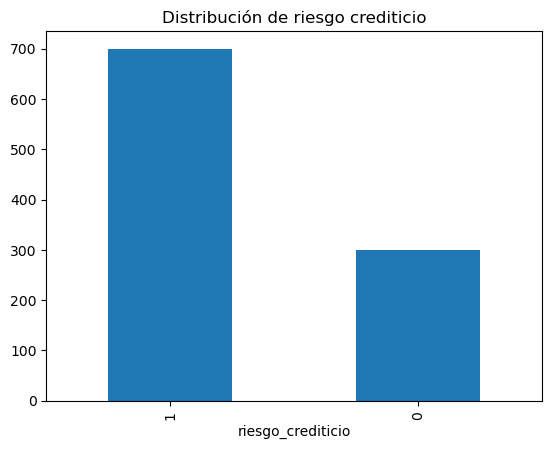

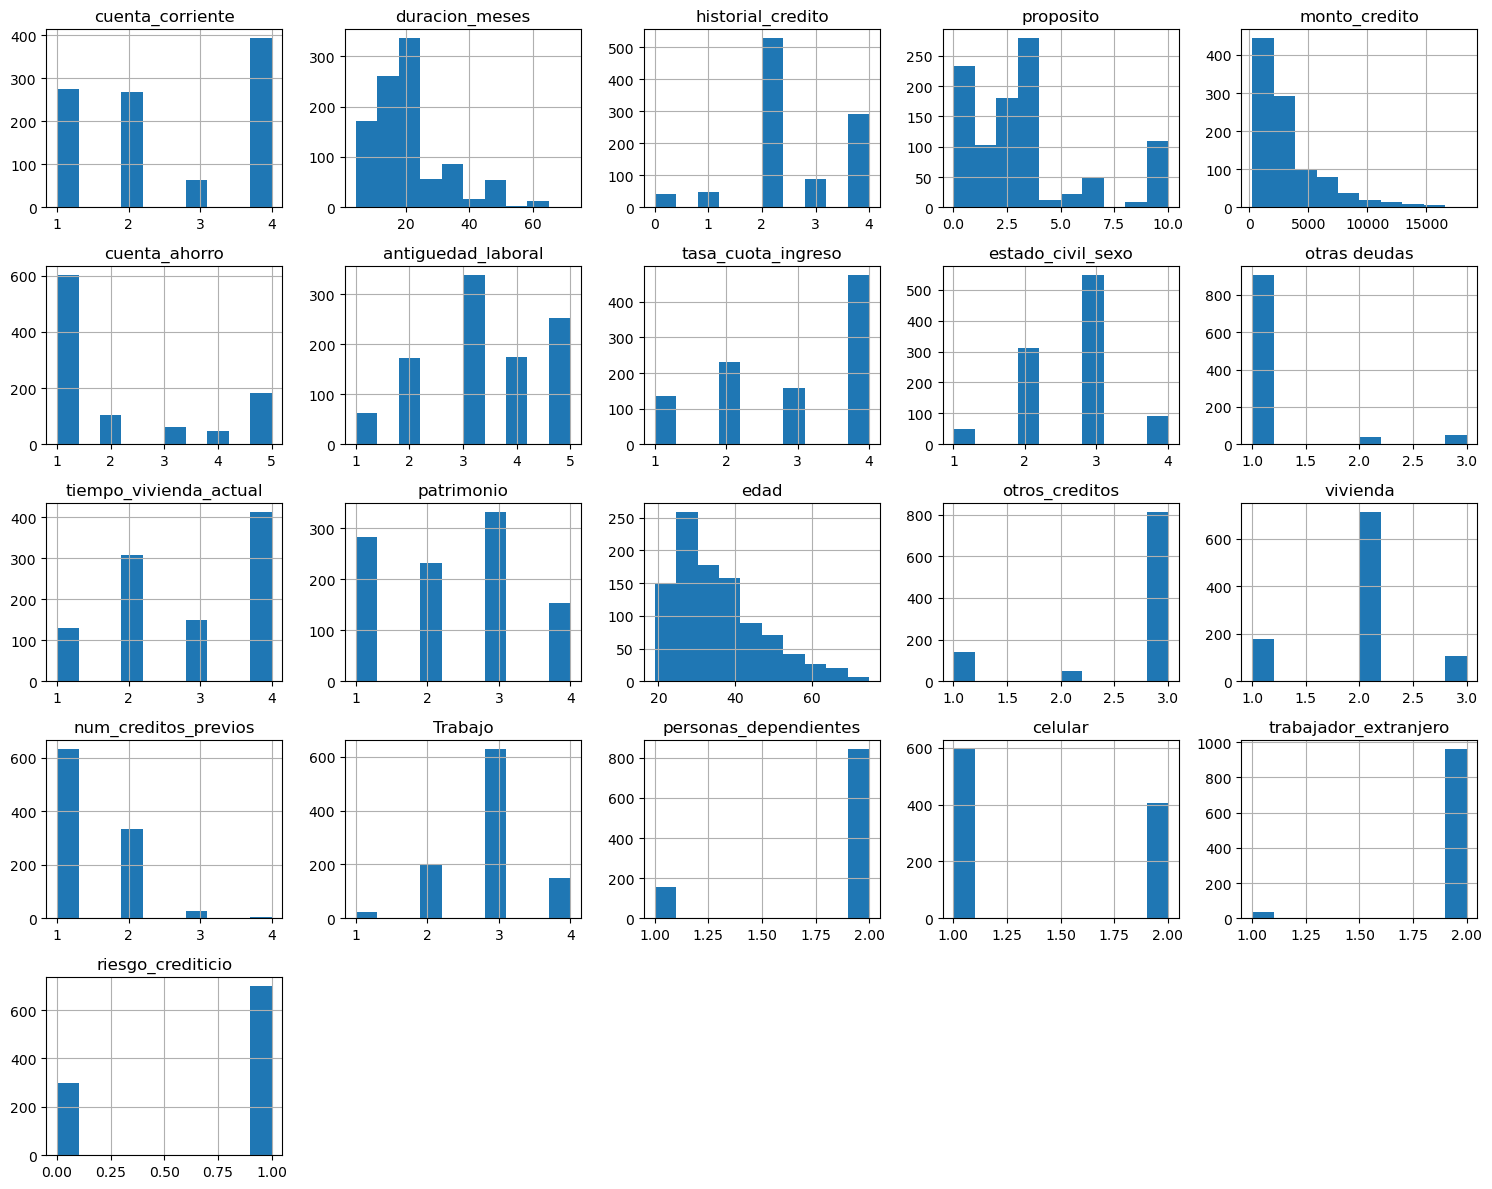

In [10]:
df['riesgo_crediticio'].value_counts().plot(kind='bar')
plt.title('Distribución de riesgo crediticio')
plt.show()

df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

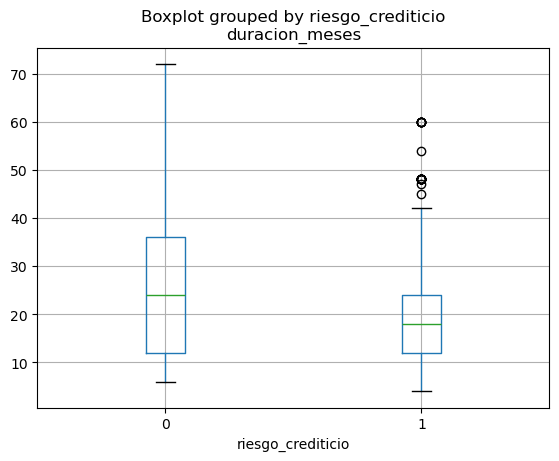

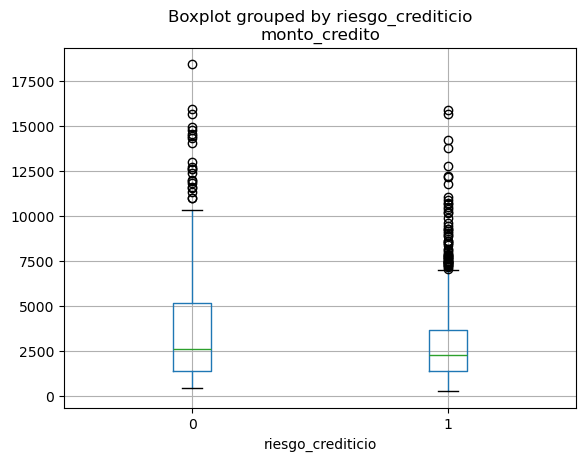

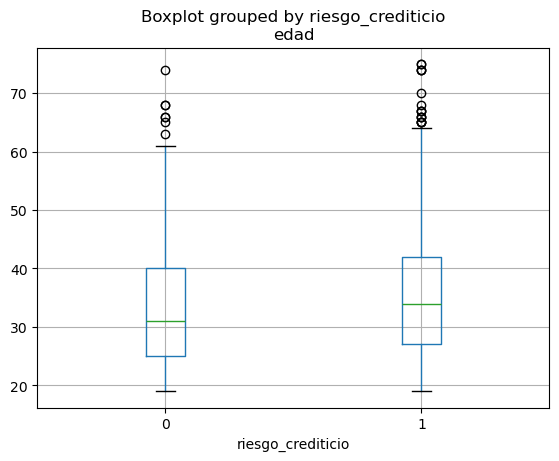

In [11]:
for col in ['duracion_meses', 'monto_credito', 'edad']:
    df.boxplot(column=col, by='riesgo_crediticio')
    plt.title(col)
    plt.show()

In [12]:
pd.crosstab(df['cuenta_corriente'], df['riesgo_crediticio'], normalize='index')

riesgo_crediticio,0,1
cuenta_corriente,,
1,0.492701,0.507299
2,0.390335,0.609665
3,0.222222,0.777778
4,0.116751,0.883249


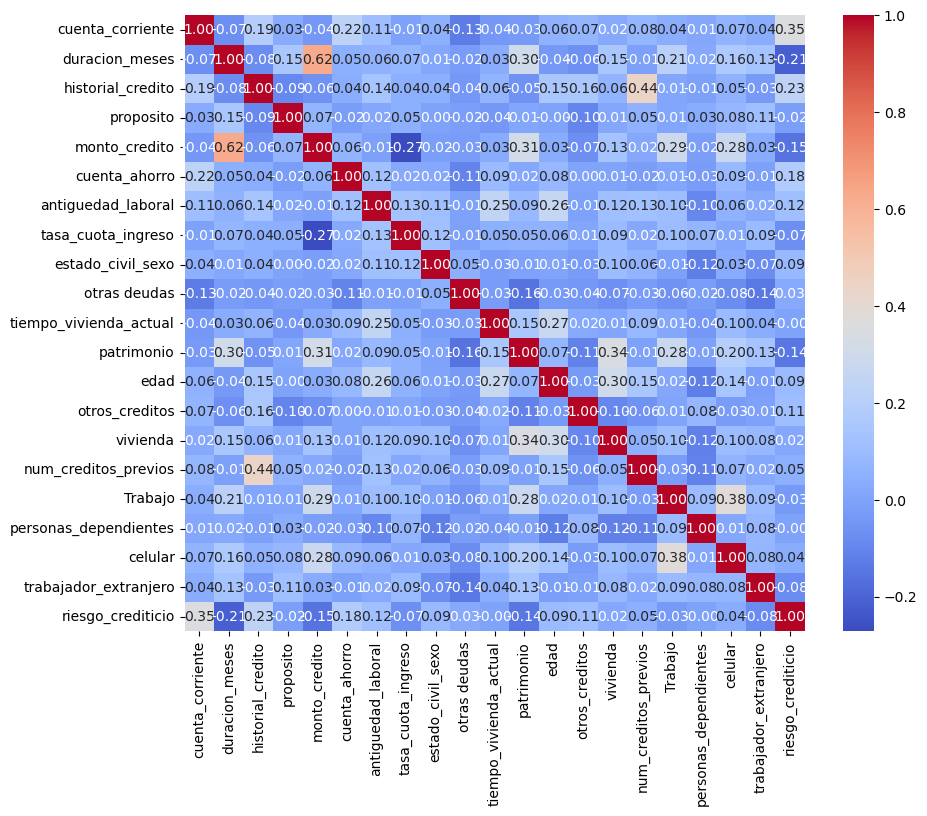

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [15]:
categoricas = ['cuenta_corriente', 'historial_credito', 'proposito', 'cuenta_ahorro',
               'antiguedad_laboral', 'estado_civil_sexo', 'otras deudas', 'patrimonio',
               'otros_creditos', 'vivienda', 'Trabajo', 'celular', 'trabajador_extranjero']

df = pd.get_dummies(df, columns=categoricas, drop_first=True)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   duracion_meses           1000 non-null   int64
 1   monto_credito            1000 non-null   int64
 2   tasa_cuota_ingreso       1000 non-null   int64
 3   tiempo_vivienda_actual   1000 non-null   int64
 4   edad                     1000 non-null   int64
 5   num_creditos_previos     1000 non-null   int64
 6   personas_dependientes    1000 non-null   int64
 7   riesgo_crediticio        1000 non-null   int64
 8   cuenta_corriente_2       1000 non-null   bool 
 9   cuenta_corriente_3       1000 non-null   bool 
 10  cuenta_corriente_4       1000 non-null   bool 
 11  historial_credito_1      1000 non-null   bool 
 12  historial_credito_2      1000 non-null   bool 
 13  historial_credito_3      1000 non-null   bool 
 14  historial_credito_4      1000 non-null   bool 
 15  propo

In [20]:
X = df.drop('riesgo_crediticio', axis=1)
y = df['riesgo_crediticio']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
scaler = StandardScaler()
cols_numericas = ['duracion_meses', 'monto_credito', 'edad']

X_train[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])
X_test[cols_numericas] = scaler.transform(X_test[cols_numericas])

In [27]:
modelo = LogisticRegression(max_iter=10000)
modelo.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [28]:
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]  # probabilidad de ser "mal pagador" (clase 1)

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.70      0.58      0.64        60
           1       0.83      0.89      0.86       140

    accuracy                           0.80       200
   macro avg       0.77      0.74      0.75       200
weighted avg       0.79      0.80      0.79       200



Clase 0 (malo pagador): precision 0.70, recall 0.58, f1 0.64, support 60, de todos los clientes que realmente son malos pagadores, el modelo solo logra identificar al 58%(recall 58%) — se le escapa un 42% de los morosos reales (falsos negativos), clasificándolos como buenos.

Clase 1 (buen pagador): precision 0.83, recall 0.89, f1 0.86, support 140
El modelo es muy bueno detectando a los buenos pagadores (89% recall), y cuando dice "es bueno", acierta el 83% de las veces.